In [1]:
import sys, os, importlib, warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
sys.path.insert(0, os.path.abspath('../../model'))
sys.path.insert(0, os.path.abspath('.'))
sys.path.insert(0, os.path.abspath('../.'))

# Cell A — forcings + wiring (Inflow__ -> Supply__), per-regime d_e and sinking
import numpy as np, matplotlib.pyplot as plt
import cariaco_obs as co
import run_baseline_diagnostic as rbd
from cariaco_baseline_setups import (
    model_baseline, model_setup_baseline, phyto_esd, zoo_esd, W_SINK)
from parscan_utils import compute_phyto_spectrum_metrics
from cariaco_obs import TARGET_BIN_DEFINITIONS

phyto_bin_defs = [b for b in TARGET_BIN_DEFINITIONS if b['type'] == 'phyto']

def regime_forcing(regime):
    obs_vec, labels, bdefs, mdf, forcing = co.load_cariaco_targets(
        regime=regime, months='hplc', agg='median')
    fn, de = forcing['Inflow__FN'], forcing['Inflow__de']
    # obs mean cell size through the identical metric pipeline as the model
    obs_phyto = np.array([obs_vec[labels.index(b['label'])] for b in phyto_bin_defs])
    obs_cent = compute_phyto_spectrum_metrics(obs_phyto, phyto_bin_defs)['centroid']
    return dict(regime=regime, FN=fn, de=de, w_over_de=W_SINK/de,
                obs_centroid=obs_cent, obs_mcs=10**obs_cent)

forc = {r: regime_forcing(r) for r in ('upwelling', 'relaxed')}
for r, f in forc.items():
    print(f"{r:10s}  F_N={f['FN']:.3f}  d_e={f['de']:.1f}  "
          f"w/d_e={f['w_over_de']:.3f}  obs mean-cell={f['obs_mcs']:.2f} µm")

upwelling   F_N=2.579  d_e=42.8  w/d_e=0.117  obs mean-cell=5.50 µm
relaxed     F_N=1.450  d_e=52.7  w/d_e=0.095  obs mean-cell=2.00 µm


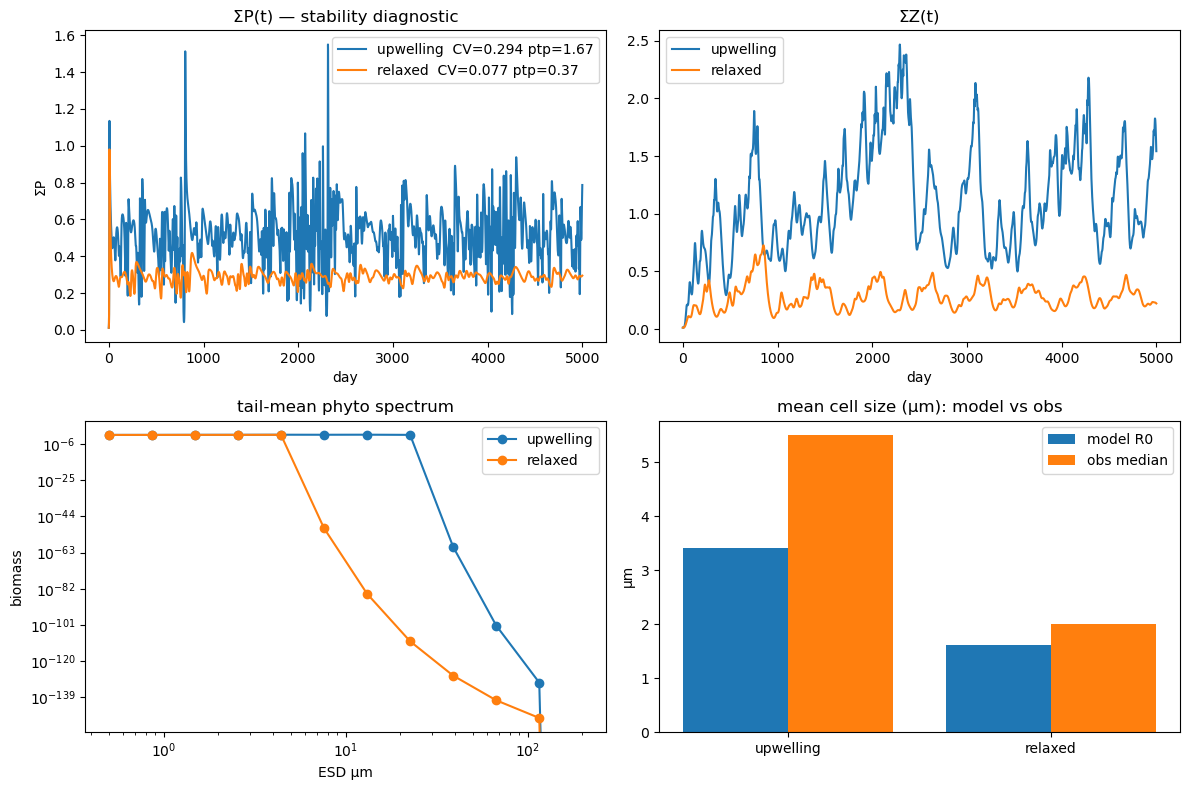

upwelling  model mean-cell=3.41 µm  obs=5.50 µm  NBSS=-1.103  CV(ΣP)=0.294
relaxed    model mean-cell=1.62 µm  obs=2.00 µm  NBSS=-19.150  CV(ΣP)=0.077


In [4]:
# Cell B — R0 (Type II, matched, no fish): run both regimes, stability + spectrum + mean cell size
TAIL = 1000
def run_regime(f):
    ov = {'Supply':      {'FN': float(f['FN']), 'de': float(f['de'])},
          'PhytoSinking': {'w_over_de': float(f['w_over_de'])}}
    out   = rbd.run_setup(model_baseline, model_setup_baseline, input_vars_override=ov)
    state = rbd.extract_state(out)
    m     = rbd.compute_metrics(state, phyto_esd, zoo_esd, tail_len=TAIL)
    sumP_t = state['P'].sum(axis=0)
    tail   = sumP_t[-TAIL:]
    cv     = tail.std() / max(tail.mean(), 1e-12)          # ~0 => settled, large => limit cycle
    ptp    = (tail.max() - tail.min()) / max(tail.mean(), 1e-12)
    return state, m, sumP_t, cv, ptp

res = {r: run_regime(f) for r, f in forc.items()}

fig, ax = plt.subplots(2, 2, figsize=(12, 8))
for r, (state, m, sumP_t, cv, ptp) in res.items():
    ax[0,0].plot(sumP_t, label=f"{r}  CV={cv:.3f} ptp={ptp:.2f}")
    ax[0,1].plot(state['Z'].sum(axis=0), label=r)
    ax[1,0].plot(phyto_esd, state['P'][:, -TAIL:].mean(axis=1), 'o-', label=r)
ax[0,0].set(title='ΣP(t) — stability diagnostic', xlabel='day', ylabel='ΣP')
ax[0,1].set(title='ΣZ(t)', xlabel='day'); ax[1,0].set(xscale='log', yscale='log',
            title='tail-mean phyto spectrum', xlabel='ESD µm', ylabel='biomass')
for a in (ax[0,0], ax[0,1], ax[1,0]): a.legend()

mcs = {r: 10**res[r][1]['centroid'] for r in forc}
xs = np.arange(2)
ax[1,1].bar(xs-0.2, [mcs[r] for r in forc], 0.4, label='model R0')
ax[1,1].bar(xs+0.2, [forc[r]['obs_mcs'] for r in forc], 0.4, label='obs median')
ax[1,1].set(xticks=xs, title='mean cell size (µm): model vs obs', ylabel='µm')
ax[1,1].set_xticklabels(list(forc)); ax[1,1].legend()
plt.tight_layout(); plt.show()

for r in forc:
    print(f"{r:10s} model mean-cell={mcs[r]:.2f} µm  obs={forc[r]['obs_mcs']:.2f} µm  "
          f"NBSS={res[r][1]['nbss_slope']:+.3f}  CV(ΣP)={res[r][3]:.3f}")

In [3]:
# Stability diagnostic across the data F_N range — Type II open Stock baseline
import numpy as np, run_baseline_diagnostic as rbd, cariaco_baseline_setups as cbs
TAIL = 1500
print(" F_N   centroid  mean_um   CV(ΣP)   ptp/mean   (CV~0 settled, large=limit cycle)")
for fn in np.linspace(0.5, 15.0, 12):
    out = rbd.run_setup(cbs.model_baseline, cbs.model_setup_baseline,
                        input_vars_override={'Supply': {'FN': float(fn)}})
    st = rbd.extract_state(out)
    m  = rbd.compute_metrics(st, cbs.phyto_esd, cbs.zoo_esd, tail_len=TAIL)
    s  = st['P'].sum(axis=0)[-TAIL:]
    cv, ptp = s.std()/max(s.mean(),1e-12), (s.max()-s.min())/max(s.mean(),1e-12)
    print(f"{fn:5.2f}  {m['centroid']:+.3f}  {10**m['centroid']:6.2f}  {cv:6.3f}  {ptp:6.3f}")

 F_N   centroid  mean_um   CV(ΣP)   ptp/mean   (CV~0 settled, large=limit cycle)
 0.50  -0.201    0.63   0.018   0.059
 1.82  +0.329    2.13   0.118   0.624
 3.14  +0.702    5.04   0.455   3.386
 4.45  +0.991    9.79   0.405   2.704
 5.77  +1.096   12.47   0.436   3.297
 7.09  +1.148   14.05   0.580   3.413
 8.41  +1.251   17.84   0.524   3.234
 9.73  +1.340   21.88   0.395   3.291
11.05  +1.178   15.07   0.773   6.025
12.36  +1.359   22.87   0.516   4.382
13.68  +1.404   25.34   0.526   4.055
15.00  +1.350   22.38   0.556   4.237
